# LeetCode #1033: Matrix Block Sum

https://leetcode.com/problems/matrix-block-sum/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(m \cdot n \cdot k^2)$ | $O(1)$ |
| **2D Prefix Sum** ★ | $O(m \cdot n)$ | $O(m \cdot n)$ |

---

## Understanding the Methods

### Brute Force
For each output cell (i, j), iterate over the full $(2k+1) \times (2k+1)$ block and accumulate the sum directly. Simple but re-computes shared sub-regions repeatedly, giving $O(k^2)$ work per cell.

### Optimal: 2D Prefix Sum ★
Build a $(m+1) \times (n+1)$ prefix table P where P[i][j] is the sum of all mat values in the top-left rectangle ending at (i−1, j−1). Any rectangular region sum is then one inclusion-exclusion formula away — four table lookups, $O(1)$ per cell.

**Why this is better than Brute Force:** Replaces the inner $O(k^2)$ loop per cell with $O(1)$ prefix-sum arithmetic, dropping total time from $O(m \cdot n \cdot k^2)$ to $O(m \cdot n)$.

**Constraints:**
* 1 ≤ m, n ≤ 100
* 1 ≤ k ≤ 100
* 1 ≤ mat[i][j] ≤ 100

## Solutions

### C#

In [ ]:
public class Solution {
    public int[][] MatrixBlockSum(int[][] mat, int k) {
        int m = mat.Length, n = mat[0].Length;

        // Build (m+1)×(n+1) prefix table — P[i][j] = sum of top-left rectangle
        int[][] p = new int[m + 1][];
        for (int i = 0; i <= m; i++) p[i] = new int[n + 1];
        for (int i = 1; i <= m; i++)
            for (int j = 1; j <= n; j++)
                p[i][j] = mat[i-1][j-1] + p[i-1][j] + p[i][j-1] - p[i-1][j-1];

        // Query each block via inclusion-exclusion on the prefix table
        int[][] answer = new int[m][];
        for (int i = 0; i < m; i++) {
            answer[i] = new int[n];
            for (int j = 0; j < n; j++) {
                int r1 = Math.Max(0, i - k), r2 = Math.Min(m - 1, i + k);
                int c1 = Math.Max(0, j - k), c2 = Math.Min(n - 1, j + k);
                answer[i][j] = p[r2+1][c2+1] - p[r1][c2+1] - p[r2+1][c1] + p[r1][c1];
            }
        }
        return answer;
    }
}

### Python

In [ ]:
class Solution:
    def matrixBlockSum(self, mat: List[List[int]], k: int) -> List[List[int]]:
        m, n = len(mat), len(mat[0])

        # Build (m+1)×(n+1) prefix table — p[i][j] = sum of top-left rectangle
        p = [[0] * (n + 1) for _ in range(m + 1)]
        for i in range(1, m + 1):
            for j in range(1, n + 1):
                p[i][j] = mat[i-1][j-1] + p[i-1][j] + p[i][j-1] - p[i-1][j-1]

        # Query each block via inclusion-exclusion on the prefix table
        answer = [[0] * n for _ in range(m)]
        for i in range(m):
            for j in range(n):
                r1, r2 = max(0, i - k), min(m - 1, i + k)
                c1, c2 = max(0, j - k), min(n - 1, j + k)
                answer[i][j] = p[r2+1][c2+1] - p[r1][c2+1] - p[r2+1][c1] + p[r1][c1]
        return answer

### Go

In [ ]:
func matrixBlockSum(mat [][]int, k int) [][]int {
    m, n := len(mat), len(mat[0])

    // Build (m+1)×(n+1) prefix table — p[i][j] = sum of top-left rectangle
    p := make([][]int, m+1)
    for i := range p {
        p[i] = make([]int, n+1)
    }
    for i := 1; i <= m; i++ {
        for j := 1; j <= n; j++ {
            p[i][j] = mat[i-1][j-1] + p[i-1][j] + p[i][j-1] - p[i-1][j-1]
        }
    }

    // Query each block via inclusion-exclusion on the prefix table
    answer := make([][]int, m)
    for i := range answer {
        answer[i] = make([]int, n)
        for j := 0; j < n; j++ {
            r1, r2 := max(0, i-k), min(m-1, i+k)
            c1, c2 := max(0, j-k), min(n-1, j+k)
            answer[i][j] = p[r2+1][c2+1] - p[r1][c2+1] - p[r2+1][c1] + p[r1][c1]
        }
    }
    return answer
}

### Rust

In [ ]:
pub fn matrix_block_sum(mat: Vec<Vec<i32>>, k: i32) -> Vec<Vec<i32>> {
    let (m, n) = (mat.len(), mat[0].len());
    let k = k as usize;

    // Build (m+1)×(n+1) prefix table — p[i][j] = sum of top-left rectangle
    let mut p = vec![vec![0i32; n + 1]; m + 1];
    for i in 1..=m {
        for j in 1..=n {
            p[i][j] = mat[i-1][j-1] + p[i-1][j] + p[i][j-1] - p[i-1][j-1];
        }
    }

    // Query each block via inclusion-exclusion on the prefix table
    (0..m).map(|i| {
        (0..n).map(|j| {
            let (r1, r2) = (i.saturating_sub(k), (i + k).min(m - 1));
            let (c1, c2) = (j.saturating_sub(k), (j + k).min(n - 1));
            p[r2+1][c2+1] - p[r1][c2+1] - p[r2+1][c1] + p[r1][c1]
        }).collect()
    }).collect()
}

## Example Scenarios

**1. Common Case**
**Input:** mat = [[1,2,3],[4,5,6],[7,8,9]], k = 1
answer[1][1]: block is entire 3×3 (radius 1 from center) → P[3][3]−P[0][3]−P[3][0]+P[0][0] = 45−0−0+0 = 45.
answer[0][0]: block clamped to rows 0–1, cols 0–1 → P[2][2]−P[0][2]−P[2][0]+P[0][0] = 12. Output: [[12,21,16],[27,45,33],[24,39,28]].

**2. Slightly Complex — k exceeds both dimensions**
**Input:** mat = [[1,2],[3,4]], k = 5
Every cell's block clamps to the full 2×2 matrix (r1=0, r2=1, c1=0, c2=1 for all cells). All four queries return P[2][2] = 1+2+3+4 = 10.
Output: [[10,10],[10,10]].

**3. Edge Case: Time Factor — speedup vs Brute Force at large k**
**Input:** 100×100 matrix, k = 50
Brute Force: each cell sums a 101×101 block → $100 \times 100 \times 101^2 \approx 10^8$ ops.
2D Prefix Sum: build P in $10^4$ ops + query in $4 \times 10^4$ ops = $5 \times 10^4$ ops total — a $\approx 2000\times$ speedup.

**4. Edge Case: Space Factor — prefix table size**
**Input:** m = n = 100, any k
Prefix table P is $(101 \times 101) = 10{,}201$ integers ($\approx 40$ KB). Answer matrix is $100 \times 100 = 10{,}000$ integers. Total extra space: $O(m \cdot n)$ — predictable and bounded regardless of k.

**5. Almost-Impossible but Plausible — single-cell matrix**
**Input:** mat = [[7]], k = 100
m=n=1, k=100. r1=max(0,0−100)=0, r2=min(0,0+100)=0, c1=0, c2=0.
P[1][1]=7. answer[0][0] = P[1][1]−P[0][1]−P[1][0]+P[0][0] = 7−0−0+0 = 7. Clamping absorbs any k without a single bounds check failing.

## Infographic

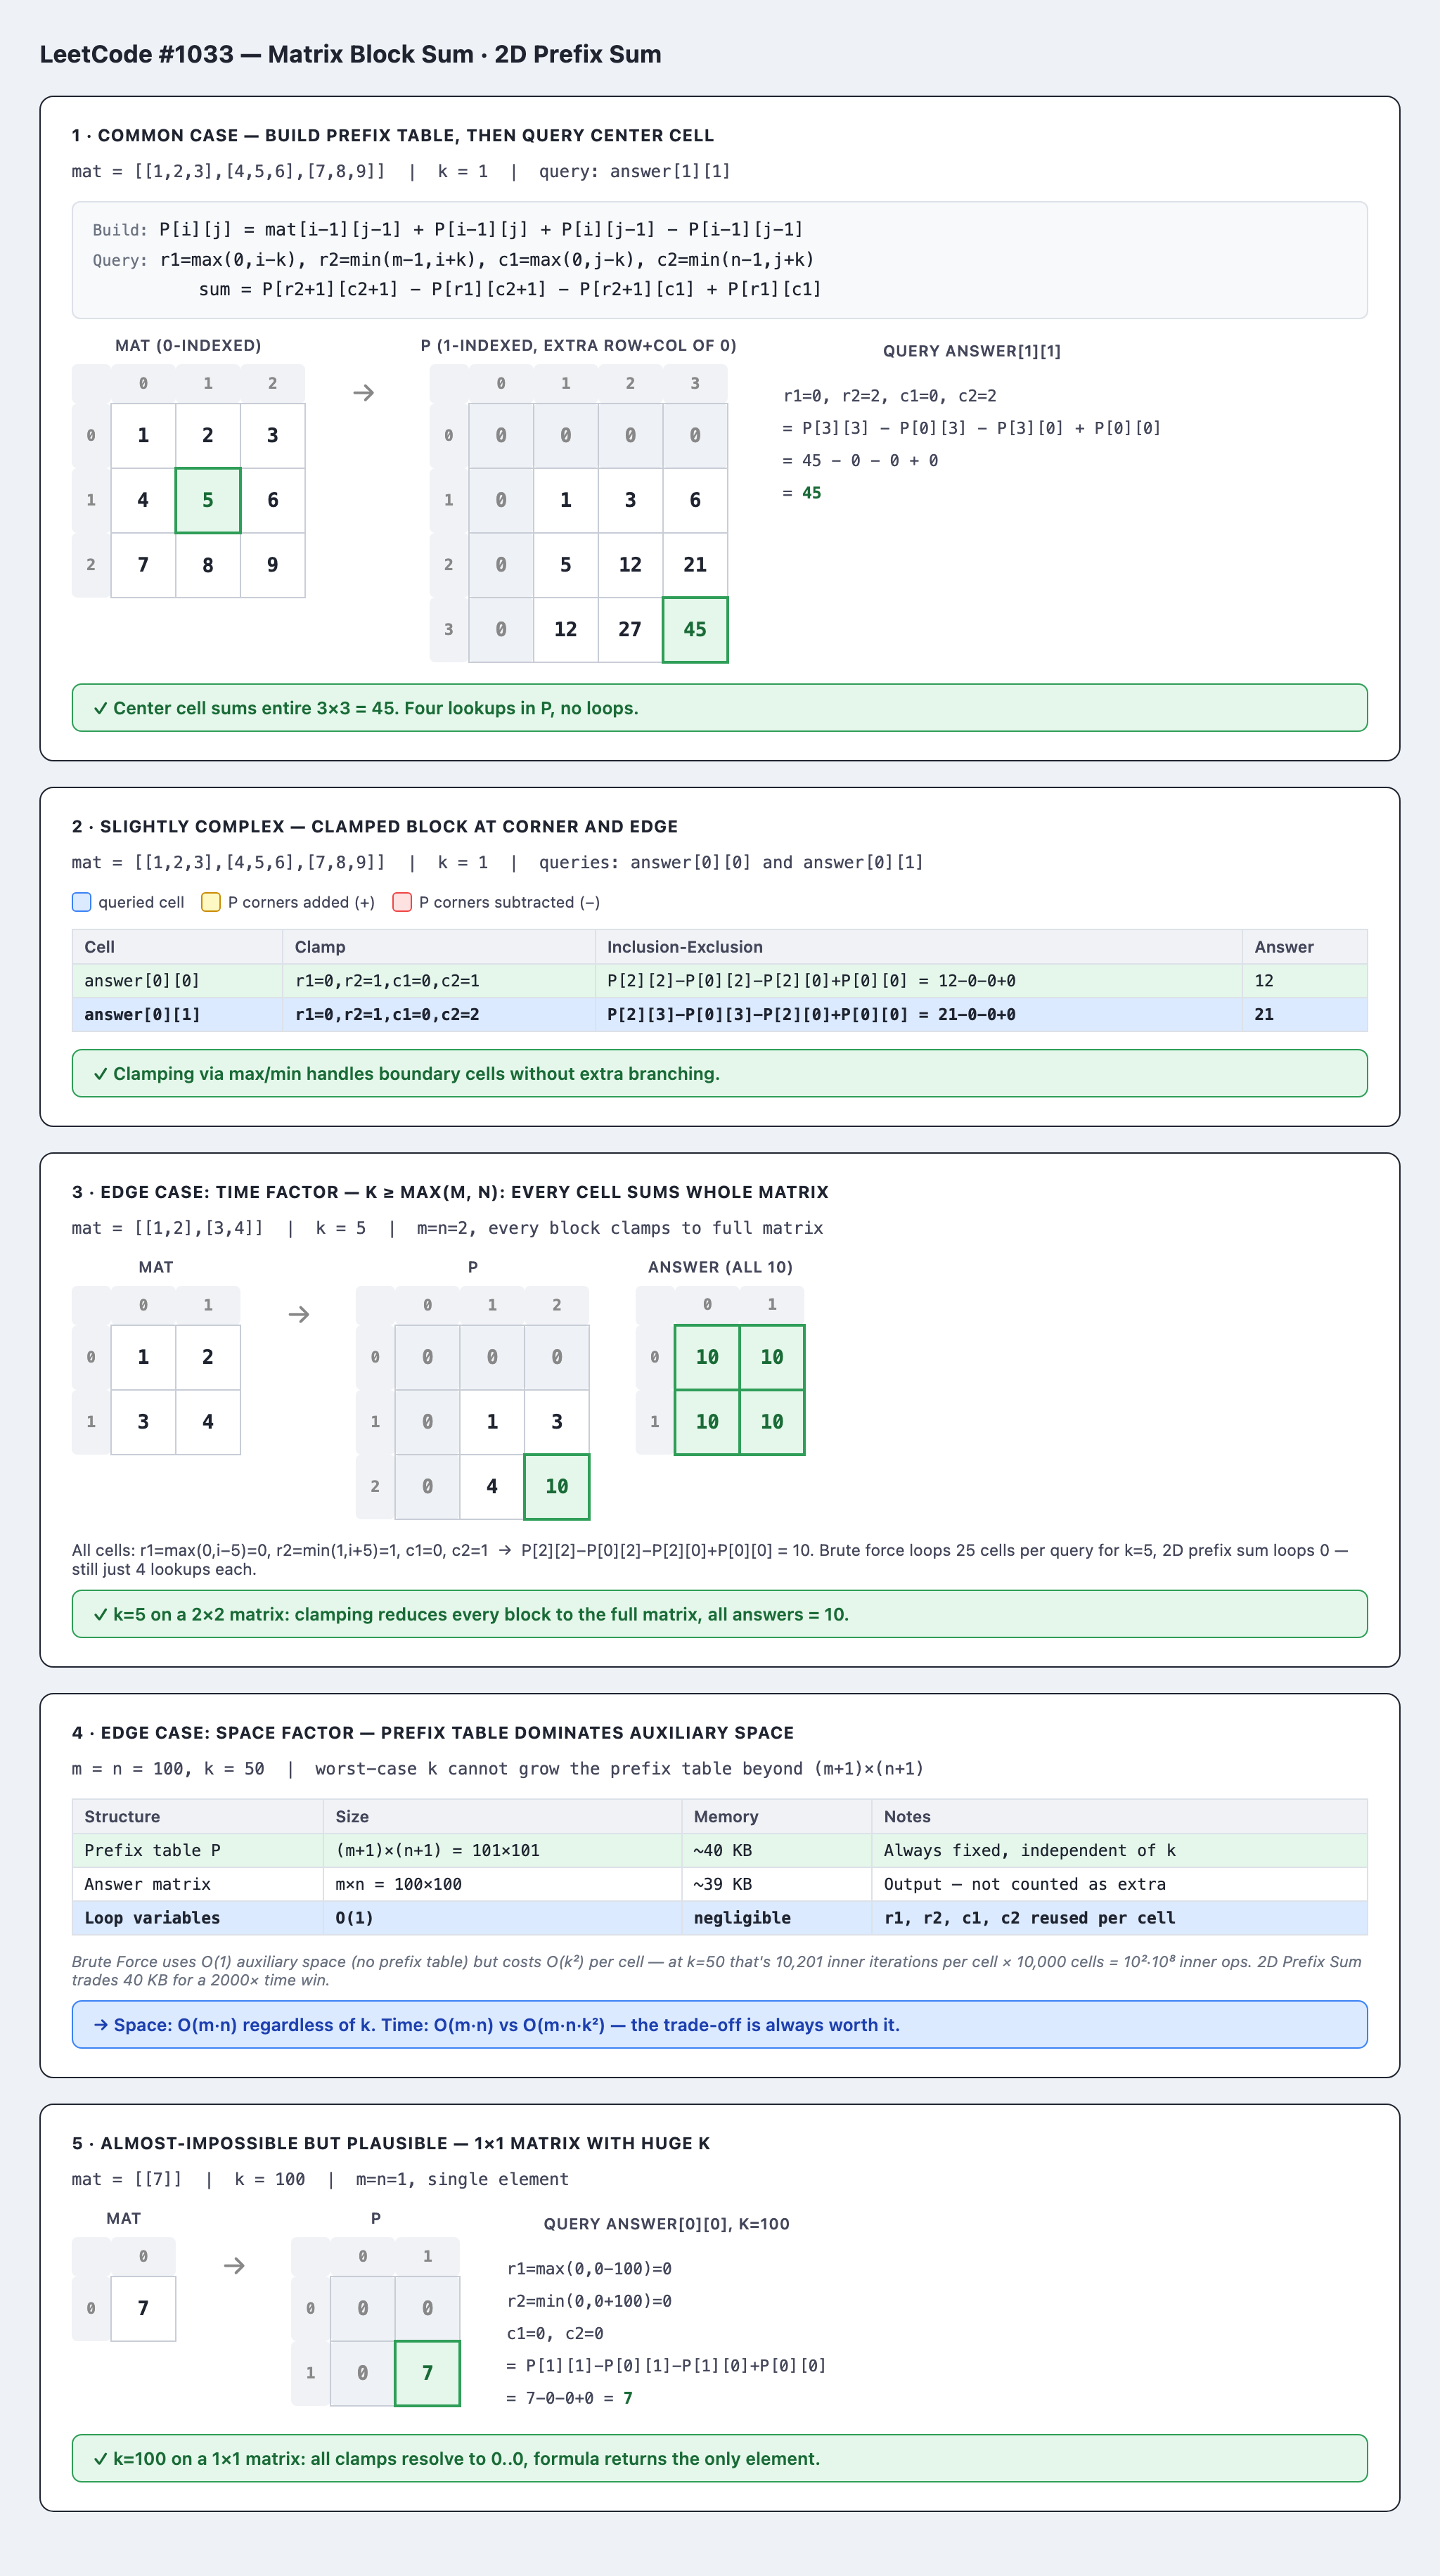